In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    concatenate
)

from tensorflow.keras.models import Model
print("imports complete")

2026-06-26 23:41:00.393320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782517260.590294      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782517260.646973      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782517261.091708      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782517261.091748      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782517261.091751      23 computation_placer.cc:177] computation placer alr

imports complete


In [2]:
DATASET_PATH = "/kaggle/input/datasets/thanhbnhphan/hc18-grand-challenge/training_set"

# Get only ultrasound images
image_files = sorted([
    f for f in os.listdir(DATASET_PATH)
    if f.endswith(".png") and "_Annotation" not in f
])

print("Total ultrasound images:", len(image_files))

# Use only a fraction of the dataset
image_files = image_files[:50]

images = []
masks = []

for image_name in image_files:

    mask_name = image_name.replace(".png", "_Annotation.png")

    image_path = os.path.join(DATASET_PATH, image_name)
    mask_path = os.path.join(DATASET_PATH, mask_name)

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"Skipping {image_name}")
        continue

    img = cv2.resize(img, (128,128))
    mask = cv2.resize(mask, (128,128))

    img = img.astype(np.float32) / 255.0
    mask = mask.astype(np.float32) / 255.0

    images.append(img)
    masks.append(mask)

X = np.array(images).reshape(-1,128,128,1)
Y = np.array(masks).reshape(-1,128,128,1)

print("Images shape:", X.shape)
print("Masks shape :", Y.shape)

Total ultrasound images: 999
Images shape: (50, 128, 128, 1)
Masks shape : (50, 128, 128, 1)


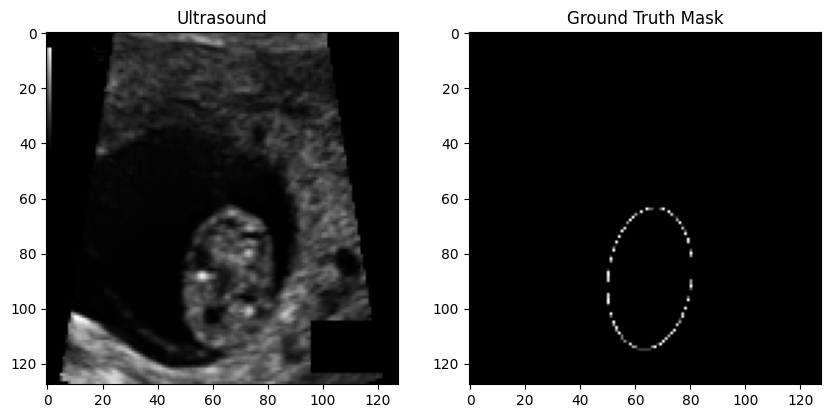

In [3]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X[0].squeeze(), cmap="gray")
plt.title("Ultrasound")

plt.subplot(1,2,2)
plt.imshow(Y[0].squeeze(), cmap="gray")
plt.title("Ground Truth Mask")

plt.show()

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (40, 128, 128, 1)
Testing : (10, 128, 128, 1)


In [5]:
inputs = Input(shape=(128,128,1))

# Encoder
c1 = Conv2D(16,3,activation='relu',padding='same')(inputs)
c1 = Conv2D(16,3,activation='relu',padding='same')(c1)
p1 = MaxPooling2D((2,2))(c1)

# Bottleneck
c2 = Conv2D(32,3,activation='relu',padding='same')(p1)
c2 = Conv2D(32,3,activation='relu',padding='same')(c2)

# Decoder
u1 = UpSampling2D((2,2))(c2)
u1 = concatenate([u1,c1])

c3 = Conv2D(16,3,activation='relu',padding='same')(u1)
c3 = Conv2D(16,3,activation='relu',padding='same')(c3)

outputs = Conv2D(1,1,activation='sigmoid')(c3)

model = Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1782517274.934576      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782517274.940643      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d_4[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │         17 │ conv2d_5[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,633 (100.13 KB)

 Trainable params: 25,633 (100.13 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=4
)

Epoch 1/5


I0000 00:00:1782517278.144821      74 service.cc:152] XLA service 0x1ec70680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782517278.144855      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782517278.144858      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782517278.641535      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-26 23:41:20.628823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 23:41:20.913671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 23:41:21.168925: E external/local_xla/xl

1/8 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.9037 - loss: 0.6919

I0000 00:00:1782517282.723294      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.9818 - loss: 0.6220 - val_accuracy: 0.9909 - val_loss: 0.4414
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9931 - loss: 0.2118 - val_accuracy: 0.9909 - val_loss: 0.0781
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9931 - loss: 0.0829 - val_accuracy: 0.9909 - val_loss: 0.1435
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9931 - loss: 0.0862 - val_accuracy: 0.9909 - val_loss: 0.0897
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9931 - loss: 0.0523 - val_accuracy: 0.9909 - val_loss: 0.0580


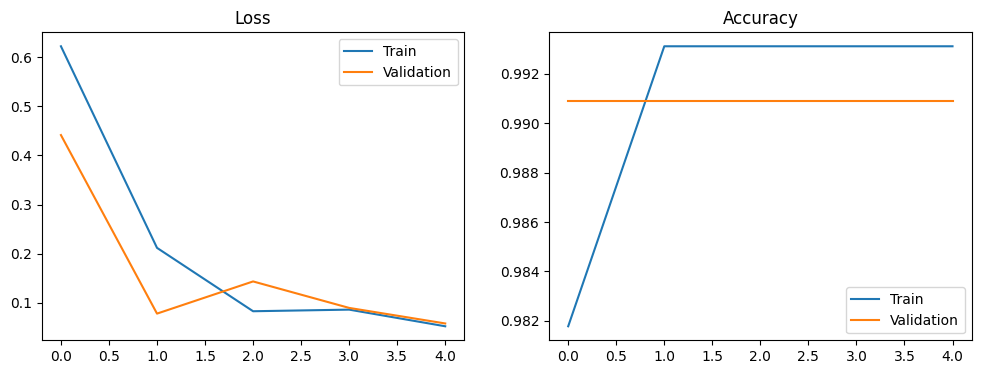

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.show()

In [8]:
prediction = model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step


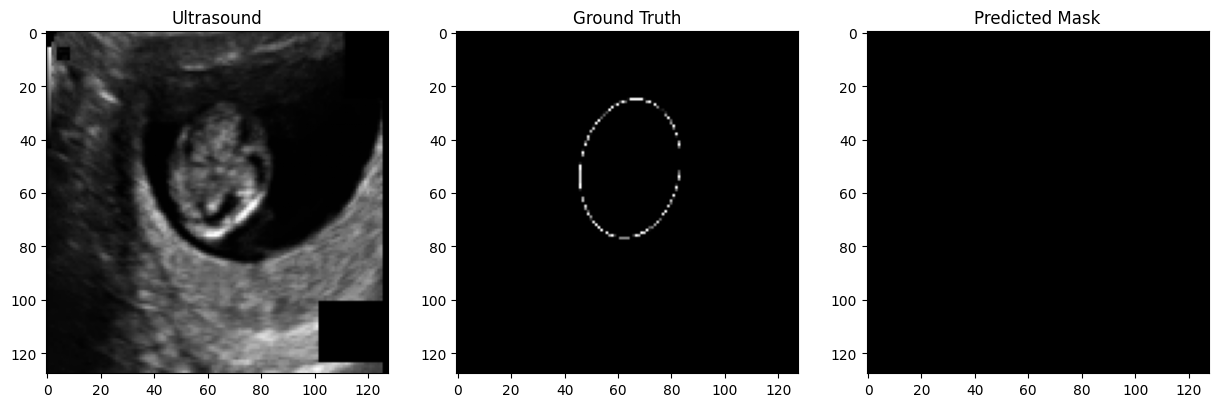

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(X_test[0].squeeze(), cmap='gray')
plt.title("Ultrasound")

plt.subplot(1,3,2)
plt.imshow(Y_test[0].squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(prediction[0].squeeze() > 0.5, cmap='gray')
plt.title("Predicted Mask")

plt.show()